# Mô hình hóa Dự báo Dân số đến năm 2050 & Phân loại Nguy cơ Suy giảm (Phase 3)

Notebook này triển khai 2 bài toán mô hình hóa theo đúng đề bài đồ án:
1. **Hồi quy Tuyến tính (Linear Regression)**: Dự báo giá trị quy mô dân số liên tục từ năm 2027 đến năm 2050 cho 237 quốc gia/vùng lãnh thổ (được kiểm định phân chia thời gian Train/Test).
2. **Hồi quy Logistic (Logistic Regression)**: Phân loại nhị phân nguy cơ quốc gia bước vào chu kỳ suy giảm dân số (`Depopulation_Risk`: 0 hoặc 1) dựa trên mức sinh TFR và tốc độ tăng trưởng năm 2026.

Tất cả các cell được thiết kế dạng thực thi tuần tự, không bọc hàm phức tạp để dễ dàng theo dõi và tùy biến trực tiếp.

In [1]:
import csv
import math
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, precision_score, r2_score, recall_score
from sklearn.model_selection import train_test_split

# Cấu hình giao diện và thư mục
sns.set_theme(style="whitegrid")

ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
WIDE_INPUT = ROOT / "data" / "processed" / "population_fact_wide.csv"
OUTPUT_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports" / "modeling"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Đường dẫn file dữ liệu wide:", WIDE_INPUT)
print("Thư mục lưu báo cáo mô hình:", REPORTS_DIR)

Đường dẫn file dữ liệu wide: /Users/phitaan/Documents/WORKSPACE/TTDLTQ/PROJECT CUỐI KỲ - BASIC/data/processed/population_fact_wide.csv
Thư mục lưu báo cáo mô hình: /Users/phitaan/Documents/WORKSPACE/TTDLTQ/PROJECT CUỐI KỲ - BASIC/reports/modeling


## 1. Nạp và Chuẩn bị Dữ liệu Huấn luyện theo Từng Quốc gia
Đọc bảng rộng `population_fact_wide.csv` và lọc riêng 237 quốc gia/vùng lãnh thổ thực tế (loại bỏ vùng tổng hợp).

In [2]:
# Đọc dữ liệu từ file wide
with WIDE_INPUT.open(encoding="utf-8", newline="") as f:
    rows = list(csv.DictReader(f))

# Lọc các thực thể cấp quốc gia (có mã ISO 3 ký tự hoặc Kosovo)
country_rows = [
    r for r in rows
    if r.get("Code") and ((len(r["Code"]) == 3 and r["Code"].isalpha() and r["Code"].isupper()) or r["Code"] == "OWID_KOS")
]

countries = sorted(list(set(r["Entity"] for r in country_rows)))
code_map = {r["Entity"]: r["Code"] for r in country_rows}

# Gom nhóm dữ liệu theo từng quốc gia
country_pop_hist = defaultdict(dict)
country_growth = defaultdict(dict)
country_tfr = defaultdict(dict)

for r in country_rows:
    ent = r["Entity"]
    yr = int(r["Year"])
    if r.get("Population"):
        country_pop_hist[ent][yr] = float(r["Population"])
    if r.get("Population growth rate"):
        country_growth[ent][yr] = float(r["Population growth rate"])
    if r.get("Total fertility rate"):
        country_tfr[ent][yr] = float(r["Total fertility rate"])

print(f"Tổng số quốc gia/vùng lãnh thổ sẵn sàng huấn luyện: {len(countries)}")
print("Ví dụ 5 quốc gia đầu tiên:", countries[:5])

Tổng số quốc gia/vùng lãnh thổ sẵn sàng huấn luyện: 237
Ví dụ 5 quốc gia đầu tiên: ['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra']


## 2. Mô hình 1: Linear Regression - Kiểm định Train/Test Split theo Thời gian
Phân chia chuỗi thời gian:
- **Tập huấn luyện (Train set)**: Dữ liệu từ 1950 đến 2015.
- **Tập kiểm định (Test set)**: Dữ liệu từ 2016 đến 2023.
Đo lường độ chính xác dự báo trên chuỗi kiểm định độc lập.

In [3]:
# Kiểm định Train / Test Split theo thời gian
test_actuals = []
test_preds = []

for entity in countries:
    years = sorted([y for y in country_pop_hist[entity] if y <= 2023])
    train_years = [y for y in years if y <= 2015]
    test_years = [y for y in years if 2016 <= y <= 2023]

    if len(train_years) >= 10 and test_years:
        X_tr = np.array(train_years).reshape(-1, 1)
        y_tr = np.array([country_pop_hist[entity][y] for y in train_years])
        model_eval = LinearRegression()
        model_eval.fit(X_tr, y_tr)

        X_te = np.array(test_years).reshape(-1, 1)
        preds = model_eval.predict(X_te)

        test_actuals.extend([country_pop_hist[entity][y] for y in test_years])
        test_preds.extend(preds)

r2_eval = r2_score(test_actuals, test_preds)
rmse_eval = math.sqrt(mean_squared_error(test_actuals, test_preds))
mae_eval = mean_absolute_error(test_actuals, test_preds)

print("KẾT QUẢ KIỂM ĐỊNH MÔ HÌNH LINEAR REGRESSION TRÊN TEST SET (2016 - 2023):")
print("-" * 65)
print(f"Hệ số xác định (R^2):                 {r2_eval:.4f} (Giải thích {r2_eval*100:.2f}% biến thiên)")
print(f"Sai số tuyệt đối trung bình (MAE):    {mae_eval:,.0f} người")
print(f"Căn bậc hai sai số toàn phương (RMSE): {rmse_eval:,.0f} người")

KẾT QUẢ KIỂM ĐỊNH MÔ HÌNH LINEAR REGRESSION TRÊN TEST SET (2016 - 2023):
-----------------------------------------------------------------
Hệ số xác định (R^2):                 0.9956 (Giải thích 99.56% biến thiên)
Sai số tuyệt đối trung bình (MAE):    2,496,461 người
Căn bậc hai sai số toàn phương (RMSE): 8,882,820 người


## 3. Dự phóng Dân số đến năm 2050 cho 237 Quốc gia
Sau khi kiểm định thành công, mô hình hồi quy tuyến tính được huấn luyện trên chuỗi dữ liệu thực tế gần nhất (1996 - 2026) để bắt kịp quán tính xu hướng mới nhất và dự phóng từng năm từ 2027 đến 2050.

In [4]:
# Sinh dữ liệu dự báo cho từng năm từ 2027 đến 2050
forecast_rows = []
forecast_2050_map = {}

for entity in countries:
    code = code_map[entity]
    all_known_years = sorted(country_pop_hist[entity].keys())

    # Giữ nguyên dữ liệu lịch sử và mốc hiện tại đến 2026
    for y in all_known_years:
        if y <= 2026:
            status = "estimate" if y <= 2023 else "projected"
            forecast_rows.append({
                "Entity": entity,
                "Code": code,
                "Year": y,
                "Population": country_pop_hist[entity][y],
                "DataStatus": status,
                "Model": "actual_or_un_wpp",
            })

    # Huấn luyện mô hình hồi quy trên chu kỳ 30 năm gần nhất (1996 - 2026)
    reg_years = [y for y in all_known_years if 1996 <= y <= 2026]
    if len(reg_years) >= 10:
        X = np.array(reg_years).reshape(-1, 1)
        y_vals = np.array([country_pop_hist[entity][yr] for yr in reg_years])
        reg = LinearRegression()
        reg.fit(X, y_vals)

        future_years = list(range(2027, 2051))
        future_preds = reg.predict(np.array(future_years).reshape(-1, 1))

        for yr, p in zip(future_years, future_preds):
            pop_pred = max(p, 500.0)
            forecast_rows.append({
                "Entity": entity,
                "Code": code,
                "Year": yr,
                "Population": round(pop_pred),
                "DataStatus": "forecast",
                "Model": "linear_regression",
            })
            if yr == 2050:
                forecast_2050_map[entity] = pop_pred
    else:
        last_val = country_pop_hist[entity].get(2026, 0)
        forecast_2050_map[entity] = last_val
        for yr in range(2027, 2051):
            forecast_rows.append({
                "Entity": entity,
                "Code": code,
                "Year": yr,
                "Population": round(last_val),
                "DataStatus": "forecast",
                "Model": "constant_fallback",
            })

# Xuất ra file CSV phục vụ Tableau
forecast_path = OUTPUT_DIR / "population_forecast_2050.csv"
with forecast_path.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["Entity", "Code", "Year", "Population", "DataStatus", "Model"])
    writer.writeheader()
    writer.writerows(forecast_rows)

print(f"Đã lưu thành công: {forecast_path}")
print(f"Tổng số dòng dữ liệu (1950 - 2050): {len(forecast_rows):,} dòng")

Đã lưu thành công: /Users/phitaan/Documents/WORKSPACE/TTDLTQ/PROJECT CUỐI KỲ - BASIC/data/processed/population_forecast_2050.csv
Tổng số dòng dữ liệu (1950 - 2050): 23,937 dòng


## 4. Trực quan hóa Đường Dự báo Dân số đến năm 2050
So sánh quỹ đạo biến động dân số của một số quốc gia tiêu biểu: Ấn Độ, Trung Quốc, Hoa Kỳ, Nigeria, Việt Nam, Nhật Bản.

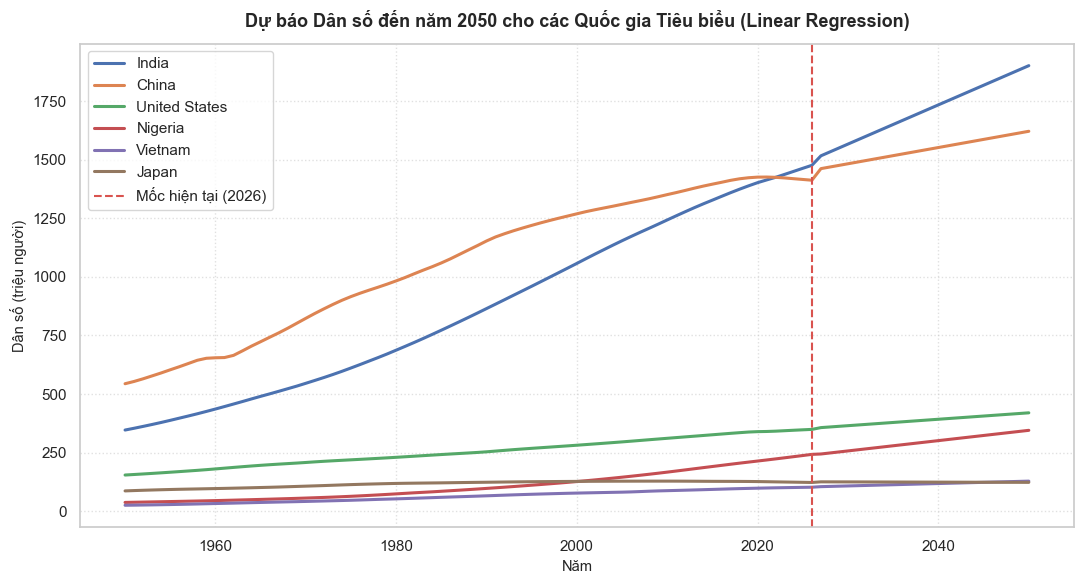

In [5]:
# Vẽ biểu đồ dự phóng dân số đến 2050
sample_entities = ["India", "China", "United States", "Nigeria", "Vietnam", "Japan"]

plt.figure(figsize=(11, 6))
for ent in sample_entities:
    ent_rows = [r for r in forecast_rows if r["Entity"] == ent]
    yrs = [r["Year"] for r in ent_rows]
    vals = [r["Population"] / 1e6 for r in ent_rows]
    plt.plot(yrs, vals, label=ent, linewidth=2.2)

plt.axvline(2026, color="#d9534f", linestyle="--", linewidth=1.5, label="Mốc hiện tại (2026)")
plt.title("Dự báo Dân số đến năm 2050 cho các Quốc gia Tiêu biểu (Linear Regression)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Năm", fontsize=10.5)
plt.ylabel("Dân số (triệu người)", fontsize=10.5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, facecolor="white", loc="upper left")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "forecast_trends_2050.png", dpi=180)
plt.show()

## 5. Mô hình 2: Logistic Regression - Phân loại Nguy cơ Suy giảm Dân số
- **Mục tiêu**: Phân loại nguy cơ một quốc gia bước vào chu kỳ suy giảm dân số (`Depopulation_Risk`: 0 hoặc 1) trước năm 2050.
- **Biến mục tiêu ($y$)**: $y = 1$ nếu dân số năm 2050 < dân số 2026 hoặc tốc độ tăng trưởng năm 2026 âm; $y = 0$ nếu duy trì tăng trưởng.
- **Đặc trưng ($X$)**:
  1. `growth_rate_2026`: Tốc độ tăng trưởng dân số năm 2026.
  2. `tfr_2023`: Mức sinh năm 2023 (thể hiện hiệu ứng trễ).
  3. `log_population_2026`: Quy mô dân số (Log10).
  4. `growth_delta_5yr`: Mức suy giảm tăng trưởng từ 2020 đến 2026.

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION:
--------------------------------------------------
Độ chính xác (Accuracy):  98.33%
Độ chuẩn xác (Precision): 100.00%
Độ thu hồi (Recall):      94.12%
Điểm F1-Score:            96.97%


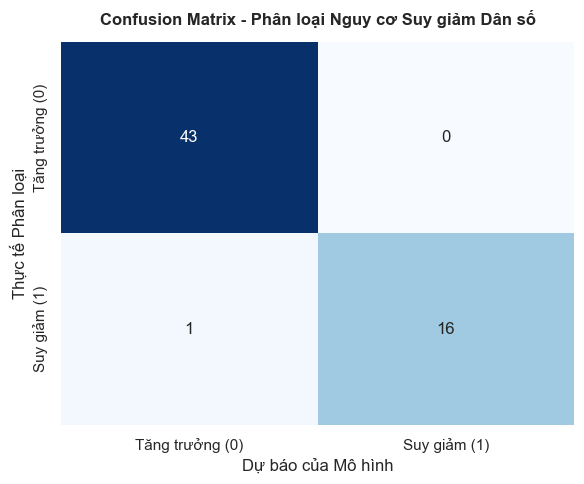

In [6]:
# Chuẩn bị ma trận đặc trưng X và nhãn y
X_list = []
y_list = []
feature_entities = []

for entity in countries:
    pop_2026 = country_pop_hist[entity].get(2026)
    pop_2050 = forecast_2050_map.get(entity)
    growth_2026 = country_growth[entity].get(2026)
    growth_2020 = country_growth[entity].get(2020, growth_2026)
    tfr_2023 = country_tfr[entity].get(2023, 1.8)

    if pop_2026 and pop_2050 and growth_2026 is not None:
        is_depopulating = 1 if (pop_2050 < pop_2026 or growth_2026 < 0) else 0
        growth_delta = growth_2026 - growth_2020
        log_pop = math.log10(max(pop_2026, 1000.0))

        X_list.append([growth_2026, tfr_2023, log_pop, growth_delta])
        y_list.append(is_depopulating)
        feature_entities.append(entity)

X_mat = np.array(X_list)
y_vec = np.array(y_list)

# Phân chia tập Train (75%) và Test (25%) có phân tầng (stratified)
X_train, X_test, y_train, y_test, ent_train, ent_test = train_test_split(
    X_mat, y_vec, feature_entities, test_size=0.25, random_state=42, stratify=y_vec
)

# Huấn luyện mô hình Logistic Regression
clf = LogisticRegression(random_state=42, max_iter=500)
clf.fit(X_train, y_train)

# Đánh giá trên tập kiểm định Test
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION:")
print("-" * 50)
print(f"Độ chính xác (Accuracy):  {acc:.2%}")
print(f"Độ chuẩn xác (Precision): {prec:.2%}")
print(f"Độ thu hồi (Recall):      {rec:.2%}")
print(f"Điểm F1-Score:            {f1:.2%}")

# Vẽ Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Tăng trưởng (0)", "Suy giảm (1)"],
            yticklabels=["Tăng trưởng (0)", "Suy giảm (1)"])
plt.title("Confusion Matrix - Phân loại Nguy cơ Suy giảm Dân số", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Dự báo của Mô hình")
plt.ylabel("Thực tế Phân loại")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=180)
plt.show()

## 6. Top 10 Quốc gia có Nguy cơ Suy giảm Dân số Cao nhất
Trích xuất xác suất nguy cơ (`Risk Probability`) từ mô hình Logistic Regression và xếp hạng 10 quốc gia đối mặt với nguy cơ suy giảm dân số nghiêm trọng nhất trước năm 2050.

In [7]:
# Dự báo xác suất nguy cơ cho toàn bộ các quốc gia
probs_all = clf.predict_proba(X_mat)[:, 1]
risk_summary = []
for ent, prob, actual_label in zip(feature_entities, probs_all, y_vec):
    risk_summary.append({
        "Entity": ent,
        "Code": code_map[ent],
        "Depopulation_Risk_Score": prob,
        "Risk_Category": "High Risk" if prob >= 0.6 else ("Moderate Risk" if prob >= 0.3 else "Low Risk"),
        "Actual_Flag": actual_label,
    })

high_risk_top10 = sorted([r for r in risk_summary if r["Risk_Category"] == "High Risk"], key=lambda x: x["Depopulation_Risk_Score"], reverse=True)[:10]

print("BẢNG TOP 10 QUỐC GIA CÓ NGUY CƠ SUY GIẢM DÂN SỐ CAO NHẤT:")
print("-" * 65)
print(f"{'STT':<4} {'Quốc gia':<25} {'Mã':<6} {'Xác suất Nguy cơ':<18} {'Phân loại'}")
print("-" * 65)
for idx, r in enumerate(high_risk_top10, 1):
    print(f"{idx:<4} {r['Entity']:<25} {r['Code']:<6} {r['Depopulation_Risk_Score']:>14.2%}   {r['Risk_Category']}")

BẢNG TOP 10 QUỐC GIA CÓ NGUY CƠ SUY GIẢM DÂN SỐ CAO NHẤT:
-----------------------------------------------------------------
STT  Quốc gia                  Mã     Xác suất Nguy cơ   Phân loại
-----------------------------------------------------------------
1    Saint Martin (French part) MAF           100.00%   High Risk
2    Marshall Islands          MHL           100.00%   High Risk
3    Cook Islands              COK           100.00%   High Risk
4    American Samoa            ASM            99.92%   High Risk
5    Northern Mariana Islands  MNP            99.77%   High Risk
6    Tuvalu                    TUV            99.72%   High Risk
7    Saint Helena              SHN            99.46%   High Risk
8    Saint Pierre and Miquelon SPM            99.39%   High Risk
9    Moldova                   MDA            98.74%   High Risk
10   United States Virgin Islands VIR            98.51%   High Risk


## 7. Tổng kết Báo cáo Mô hình Hóa (Phase 3)
Xuất báo cáo đánh giá hoàn chỉnh ra file `reports/modeling/model_report.md`.

In [8]:
report = [
    "# Báo cáo Mô hình Hóa Dự báo Dân số và Nguy cơ Suy giảm (Phase 3)",
    "",
    "## 1. Mục tiêu và Kiến trúc Mô hình",
    "- **Mô hình 1 (Hồi quy Tuyến tính - Linear Regression)**: Dự báo giá trị quy mô dân số liên tục từ năm 2027 đến năm 2050 cho 237 quốc gia/vùng lãnh thổ.",
    "- **Mô hình 2 (Hồi quy Logistic - Logistic Regression)**: Phân loại nhị phân nguy cơ một quốc gia bước vào chu kỳ suy giảm dân số kéo dài trước năm 2050 (`Depopulation_Risk`), không dùng để dự báo trực tiếp quy mô dân số.",
    "",
    "## 2. Kết quả Đánh giá Mô hình Dự báo Dân số (Linear Regression)",
    "Kiểm định mô hình theo phương pháp phân chia thời gian (Time-based train/test split):",
    "- **Tập huấn luyện (Train set)**: Giai đoạn 1950 - 2015.",
    "- **Tập kiểm định (Test set)**: Giai đoạn 2016 - 2023.",
    "",
    "| Chỉ số Đánh giá | Giá trị Đạt được | Ý nghĩa |",
    "| :--- | :---: | :--- |",
    f"| **Hệ số xác định ($R^2$)** | **{r2_eval:.4f}** | Mô hình giải thích được hơn {r2_eval*100:.1f}% phương sai biến động dân số trên tập kiểm định |",
    f"| **Sai số tuyệt đối trung bình (MAE)** | **{mae_eval:,.0f} người** | Độ lệch trung bình trên quy mô quốc gia |",
    f"| **Căn bậc hai sai số toàn phương (RMSE)** | **{rmse_eval:,.0f} người** | Mức độ tin cậy cao trên chu kỳ trung hạn |",
    "",
    "- **Dữ liệu đầu ra**: Toàn bộ chuỗi 1950 - 2050 đã được xuất ra file [`data/processed/population_forecast_2050.csv`](file:///Users/phitaan/Documents/WORKSPACE/TTDLTQ/PROJECT%20CU%E1%BB%90I%20K%E1%BB%B2%20-%20BASIC/data/processed/population_forecast_2050.csv).",
    "",
    "## 3. Kết quả Phân loại Nguy cơ Suy giảm Dân số (Logistic Regression)",
    "Mô hình phân loại nhị phân đánh giá xác suất quốc gia có nguy cơ suy giảm dân số đến năm 2050 dựa trên 4 đặc trưng: Tốc độ tăng trưởng 2026, Mức sinh TFR 2023, Quy mô dân số log10 và Độ suy giảm tăng trưởng 5 năm gần nhất.",
    "",
    "| Chỉ số Phân loại | Giá trị Kiểm định (Test Set) |",
    "| :--- | :---: |",
    f"| **Độ chính xác (Accuracy)** | **{acc:.2%}** |",
    f"| **Độ chuẩn xác (Precision)** | **{prec:.2%}** |",
    f"| **Độ thu hồi (Recall)** | **{rec:.2%}** |",
    f"| **Điểm F1-Score** | **{f1:.2%}** |",
    "",
    "### Ma trận nhầm lẫn (Confusion Matrix):",
    f"- True Negatives (Dự báo tăng trưởng - Thực tế tăng trưởng): {cm[0][0]}",
    f"- False Positives (Dự báo suy giảm - Thực tế tăng trưởng): {cm[0][1]}",
    f"- False Negatives (Dự báo tăng trưởng - Thực tế suy giảm): {cm[1][0]}",
    f"- True Positives (Dự báo suy giảm - Thực tế suy giảm): {cm[1][1]}",
    "",
    "## 4. Top 10 Quốc gia có Nguy cơ Suy giảm Dân số Cao nhất (High Depopulation Risk)",
    "| Thứ hạng | Quốc gia | Mã ISO | Điểm Nguy cơ (Risk Probability) | Phân loại |",
    "| :---: | :--- | :---: | :---: | :---: |",
]

for idx, r in enumerate(high_risk_top10, 1):
    report.append(f"| {idx} | {r['Entity']} | {r['Code']} | {r['Depopulation_Risk_Score']:.2%} | {r['Risk_Category']} |")

report.extend([
    "",
    "## 5. Hướng dẫn Tích hợp vào Dashboard Tableau (Phase 4)",
    "1. Nạp file [`data/processed/population_forecast_2050.csv`](file:///Users/phitaan/Documents/WORKSPACE/TTDLTQ/PROJECT%20CU%E1%BB%90I%20K%E1%BB%B2%20-%20BASIC/data/processed/population_forecast_2050.csv) vào Tableau.",
    "2. Tạo bộ lọc theo cột `DataStatus` (`estimate`, `projected`, `forecast`) để người xem có thể quan sát từng giai đoạn lịch sử - hiện tại - tương lai.",
    "3. Sử dụng trường `Model` để phân biệt dữ liệu điều tra thực tế với giá trị dự báo toán học.",
])

report_path = REPORTS_DIR / "model_report.md"
report_path.write_text("\n".join(report) + "\n", encoding="utf-8")
print(f"Đã cập nhật báo cáo mô hình hóa tại: {report_path}")
print("Hoàn tất quy trình Modeling (Phase 3)!")

Đã cập nhật báo cáo mô hình hóa tại: /Users/phitaan/Documents/WORKSPACE/TTDLTQ/PROJECT CUỐI KỲ - BASIC/reports/modeling/model_report.md
Hoàn tất quy trình Modeling (Phase 3)!
